# SQL E-commerce Revenue Analysis

This notebook analyzes user purchase behavior and revenue patterns  
using BigQuery's public `thelook_ecommerce` dataset.

SQL queries were written in BigQuery to extract pre-aggregated results,  
which are then loaded here for visualization and interpretation.

The analysis focuses on three key questions:
1. How do new and returning users differ in revenue contribution?
2. Which product categories drive the most revenue?
3. How does price segmentation influence revenue generation?

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_user = pd.read_csv("New vs Returning.csv")
df_category = pd.read_csv("Category Analysis.csv")
df_price = pd.read_csv("Price Analysis Query Result.csv")

This step is to load the pre-aggregated analysis results for each section of the project.

- `df_user`: comparison of new vs returning users
- `df_category`: category-level revenue and purchase behavior
- `df_price`: price-segment revenue analysis

These datasets are used directly for visualization and interpretation.

## 2. New vs Returning Users
### Objective

To compare revenue contribution and purchasing behavior between new and returning users.

### Data Overview

This dataset contains aggregated metrics for new and returning users, including total orders and total revenue.

In [3]:
df_user.head()

,user_type,user_count,order_count,revenue,avg_price_per_item
0,New,80106,80106,6.907690e+06,59.452187
1,Returning,29970,45165,3.921182e+06,59.745888


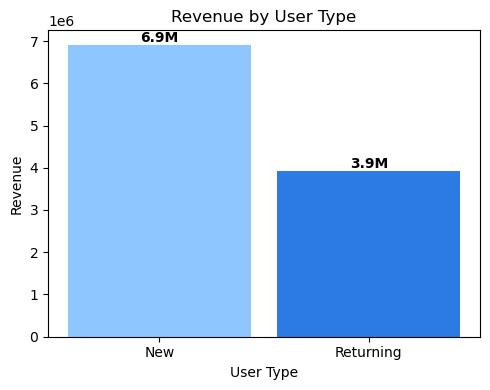

In [4]:
x = np.array([0, 0.4]) #To reduce the empty space between two bar graphs

fig, ax = plt.subplots(figsize=(5, 4), dpi=100)

colors = ['#8EC6FF', '#2C7BE5'] # highlighing returning with colors

bars = ax.bar(x, df_user["revenue"], width=0.35, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(df_user["user_type"])

ax.set_xlabel("User Type")
ax.set_ylabel("Revenue")
ax.set_title("Revenue by User Type")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, # center align for the bar graph
        height,
        f'{height/1e6:.1f}M', #converting units in millions
        ha='center', # center align for the text
        va='bottom', # aligning the text on its lowest line
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig("revenue_by_user_type.png", dpi=300, bbox_inches='tight')
plt.show()

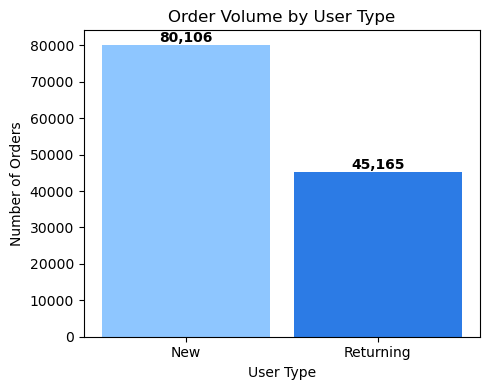

In [5]:
x = np.array([0, 0.4]) #To reduce the empty space between two bar graphs

fig, ax = plt.subplots(figsize=(5, 4), dpi=100)

# Color Mapping. Used a different method than the above to highlight the 'returning' section
color_map = {
    'New': '#8EC6FF',
    'Returning': '#2C7BE5'
}
colors = [color_map[user] for user in df_user["user_type"]]

bars = ax.bar(x, df_user["order_count"], width=0.35, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(df_user["user_type"])

ax.set_xlabel("User Type")
ax.set_ylabel("Number of Orders")
ax.set_title("Order Volume by User Type")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height):,}',  # using comma to make numbers easiers to read
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig("order_volume_by_user_type.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight

New users generate higher total revenue in absolute terms, primarily due to their larger population size (approximately 80K vs 30K).
However, this gap is not driven by differences in purchasing behavior.

On a per-user basis, returning users demonstrate stronger engagement.
They place 1.51x more orders per user (1.51 vs 1.0), while maintaining nearly identical average order values (59.75 USD vs 59.45 USD).

This indicates that revenue growth is driven by purchase frequency rather than pricing.

From a business perspective, improving retention is a more efficient and sustainable strategy for revenue growth than relying solely on new user acquisition.

**Key Takeaway:** Retention-driven strategies are more effective than acquisition-driven growth for increasing revenue.

## 3. Category Analysis

### Objective

To identify which product categories drive revenue and how purchasing behavior differs across categories.

### Data Overview

This dataset contains aggregated metrics by product category.

- `purchase_count`: total number of items purchased
- `order_count`: total number of orders placed (one order may contain multiple items)
- `revenue`: generated total revenue
- `avg_price`: average item price within the category

In [6]:
df_category.head()

,category,purchase_count,order_count,revenue,avg_price
0,Outerwear & Coats,9017,8813,1.301914e+06,144.384343
1,Jeans,12774,12347,1.243124e+06,97.316774
2,Sweaters,11107,10804,8.360638e+05,75.273596
3,Suits & Sport Coats,5167,5030,6.586818e+05,127.478585
4,Swim,11382,11069,6.464580e+05,56.796524


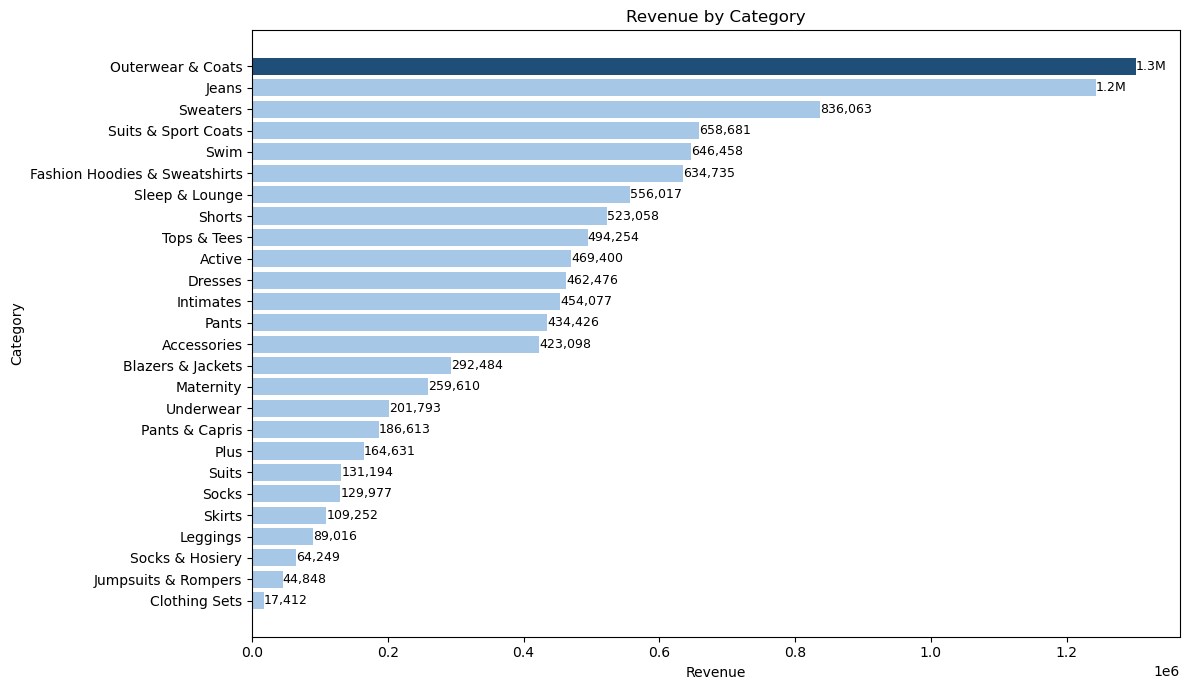

In [7]:
# 1. Alignment, ascending=True so that the highest value appears at the top of the horizontal bar chart
df_sorted = df_category.sort_values(by="revenue", ascending=True) 

# 2. Color
colors = ['#A7C7E7'] * len(df_sorted)
colors[-1] = '#1F4E79'  # Highlighted only Top 1, rest the same

# 3. Graph itself 
fig, ax = plt.subplots(figsize=(12, 7), dpi=100)

bars = ax.barh(df_sorted["category"], df_sorted["revenue"], color=colors)

# 4. Value settings
for bar in bars:
    width = bar.get_width()
    
# Converting units to M that are above millions, rest as is.
    if width >= 1e6: 
        label = f'{width/1e6:.1f}M'
    else:
        label = f'{int(width):,}'

    ax.text(
        width + 200,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center',
        fontsize=9
    )

# 5. Labels for each axis / title
ax.set_xlabel("Revenue")
ax.set_ylabel("Category")
ax.set_title("Revenue by Category")

plt.tight_layout()
plt.savefig("revenue_by_category.png", dpi=300, bbox_inches='tight')
plt.show()

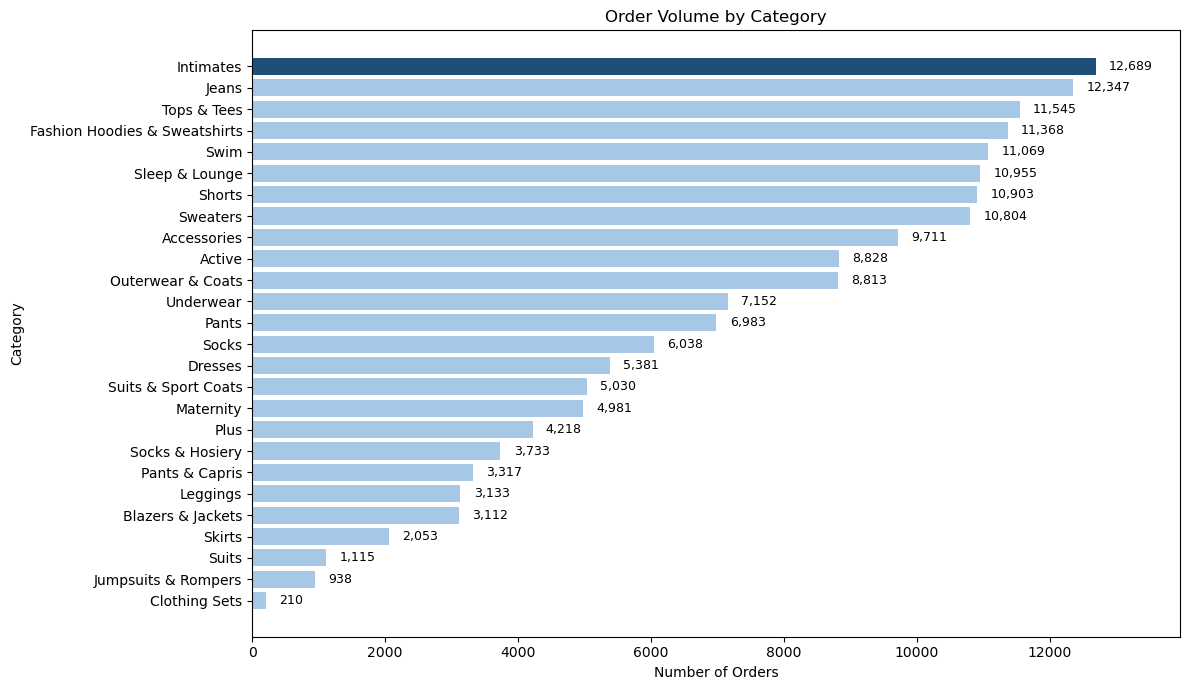

In [8]:
# 1. Alignment
df_sorted_order = df_category.sort_values(by="order_count", ascending=True)

# 2. Same color logic as the graph above
colors = ['#A7C7E7'] * len(df_sorted_order)
colors[-1] = '#1F4E79'

# 3. Graph itself
fig, ax = plt.subplots(figsize=(12, 7), dpi=100)

bars = ax.barh(df_sorted_order["category"], df_sorted_order["order_count"], color=colors)

#4. Value settings
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 200,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width):,}',
        va='center',
        fontsize=9
    )

ax.set_xlim(0, df_sorted_order["order_count"].max() * 1.1) # Due to numbers overflowing, made the X-axis longer

# 5. Labels for each axis / title
ax.set_xlabel("Number of Orders")
ax.set_ylabel("Category")
ax.set_title("Order Volume by Category")

plt.tight_layout()
plt.savefig("order_volume_by_category.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight

Category performance is driven by two distinct mechanics: purchase volume and transaction value.

Outerwear & Coats generates the highest revenue (~1.3M USD) with only 8,813 orders, ranking well below the top in order volume. This indicates that its revenue strength comes from higher average prices (144.4 USD per item) rather than sales frequency.

In contrast, Intimates records the highest order count (12,689) but ranks significantly lower in revenue (~454K USD), reflecting a volume-driven pattern with lower value per transaction (avg price: 33.4 USD).

This divergence shows that high sales volume does not necessarily translate into high revenue. Categories like Outerwear generate stronger revenue through fewer but higher-value transactions, while categories like Intimates rely on frequency.

From a business perspective, these patterns suggest that category strategies should be differentiated: volume-driven categories may benefit from repeat-purchase optimization and traffic growth, while value-driven categories offer revenue upside through premium positioning 
and upselling.

**Key Takeaway:** Revenue per category is shaped more by average transaction value than by 
order volume alone.

## 4. Price Analysis

### Objective

To analyze how different price segments influence purchasing behavior and revenue generation.

### Data Overview

This dataset contains aggregated metrics by price segment, including total purchases and total revenue.

In [9]:
df_price.head()

,price_band,purchase_count,order_count,revenue,avg_price
0,High,36790,33661,5.624792e+06,152.889166
1,Mid,77772,65058,3.913252e+06,50.316978
2,Low,67258,57467,1.290828e+06,19.192186


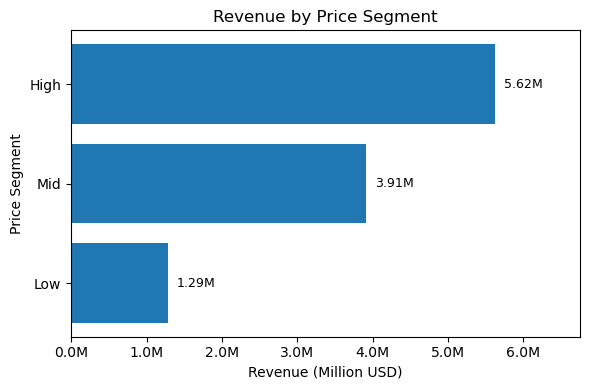

In [10]:
# Alignment
df_price_sorted = df_price.sort_values(by="revenue", ascending=True)

plt.figure(figsize=(6, 4))

bars = plt.barh(df_price_sorted["price_band"], df_price_sorted["revenue"])

plt.xlabel("Revenue (Million USD)")
plt.ylabel("Price Segment")
plt.title("Revenue by Price Segment")

# x-axis value settings
plt.gca().xaxis.set_major_formatter(lambda x, _: f'{x/1e6:.1f}M')

# Bar graph labels
max_value = df_price_sorted["revenue"].max()
plt.xlim(0, max_value * 1.2)


for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max_value * 0.02,
        bar.get_y() + bar.get_height()/2,
        f'{width/1e6:.2f}M',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig("revenue_by_price_segment.png", dpi=300, bbox_inches='tight')
plt.show()

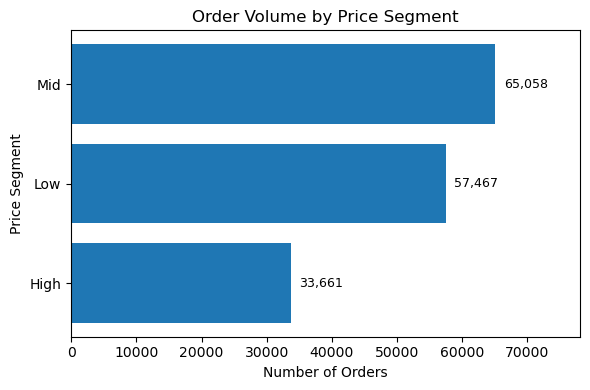

In [11]:
# Alignment
df_price_sorted_order = df_price.sort_values(by="order_count", ascending=True)

plt.figure(figsize=(6, 4))

bars = plt.barh(df_price_sorted_order["price_band"], df_price_sorted_order["order_count"])

plt.xlabel("Number of Orders")
plt.ylabel("Price Segment")
plt.title("Order Volume by Price Segment")

# x-axis value & space settings
max_value = df_price_sorted_order["order_count"].max()
plt.xlim(0, max_value * 1.2)

# Bar graph labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max_value * 0.02,
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig("order_volume_by_price_segment.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight

The relationship between price and revenue reveals a clear structural pattern: higher-priced segments dominate revenue, while mid-priced segments lead in purchase volume.

The High price segment generates the largest share of revenue (~5.6M USD) despite having the lowest number of orders, indicating that revenue is driven by higher transaction value rather than frequency.

In contrast, the Mid price segment records the highest number of orders but contributes less to total revenue, suggesting a volume-driven purchasing pattern with lower value per transaction.

This divergence highlights that purchase frequency alone does not determine revenue performance. Instead, transaction value plays a more significant role in revenue generation.

From a business perspective, this suggests that strategies focused on increasing average order value—such as premium positioning, product bundling, and targeted upselling—are likely to be more effective than those focused solely on increasing purchase volume.

## Conclusion

This analysis demonstrates that revenue growth is not driven by transaction volume alone.

Across all analyses, two key factors consistently emerge:

- **Purchase frequency**: Returning users place 1.51x more orders per user  
  at nearly identical average prices (59.75 USD vs 59.45 USD).
- **Price**: The high-price segment generates ~4.4x more revenue per purchase  
  than the low-price segment (152.9 USD vs 19.2 USD avg price).

These findings suggest that prioritizing user retention and high-value product  
offerings may be a more capital-efficient growth strategy than focusing on  
new user acquisition alone.